# Example for bssunfold package with Tomography Algorithms

This notebook demonstrates tomographic reconstruction methods adapted for neutron spectrum unfolding:
- `unfold_bsrem`: Block-Sequential Regularized Expectation Maximization
- `unfold_mapem`: Maximum A Posteriori Expectation Maximization
- `unfold_osem`: Ordered Subsets Expectation Maximization
- `unfold_sart`: Simultaneous Algebraic Reconstruction Technique

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL
from bssunfold.utils.plotting import plot_comparison

## Setup detector and reference spectrum

In [12]:
det = Detector(RF_LANL)
reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = det.get_effective_readings_for_spectra(reference_spectrum[['E_MeV','ISO_ref_Cf252']])

## Apply tomography-based unfolding methods

In [13]:
# BSREM method
result_bsrem = det.unfold_bsrem(readings)

# MAP-EM method
result_mapem = det.unfold_mapem(readings)

# OSEM method
result_osem = det.unfold_osem(readings)

# SART method
result_sart = det.unfold_sart(readings)

## Plot comparison of results

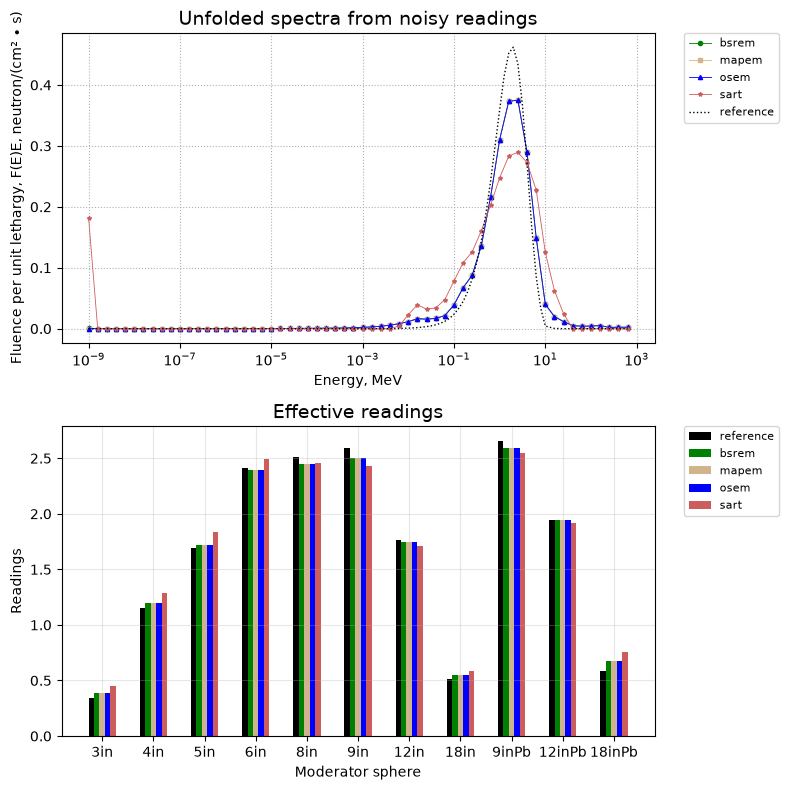

In [14]:
results = {
    "bsrem": result_bsrem,
    "mapem": result_mapem,
    "osem": result_osem,
    "sart": result_sart,
}

fig, ax = plot_comparison(
    results=results,
    readings=readings,
    reference_spectrum=reference_spectrum[["E_MeV", "ISO_ref_Cf252"]],
)

## Spectrum plots for each method

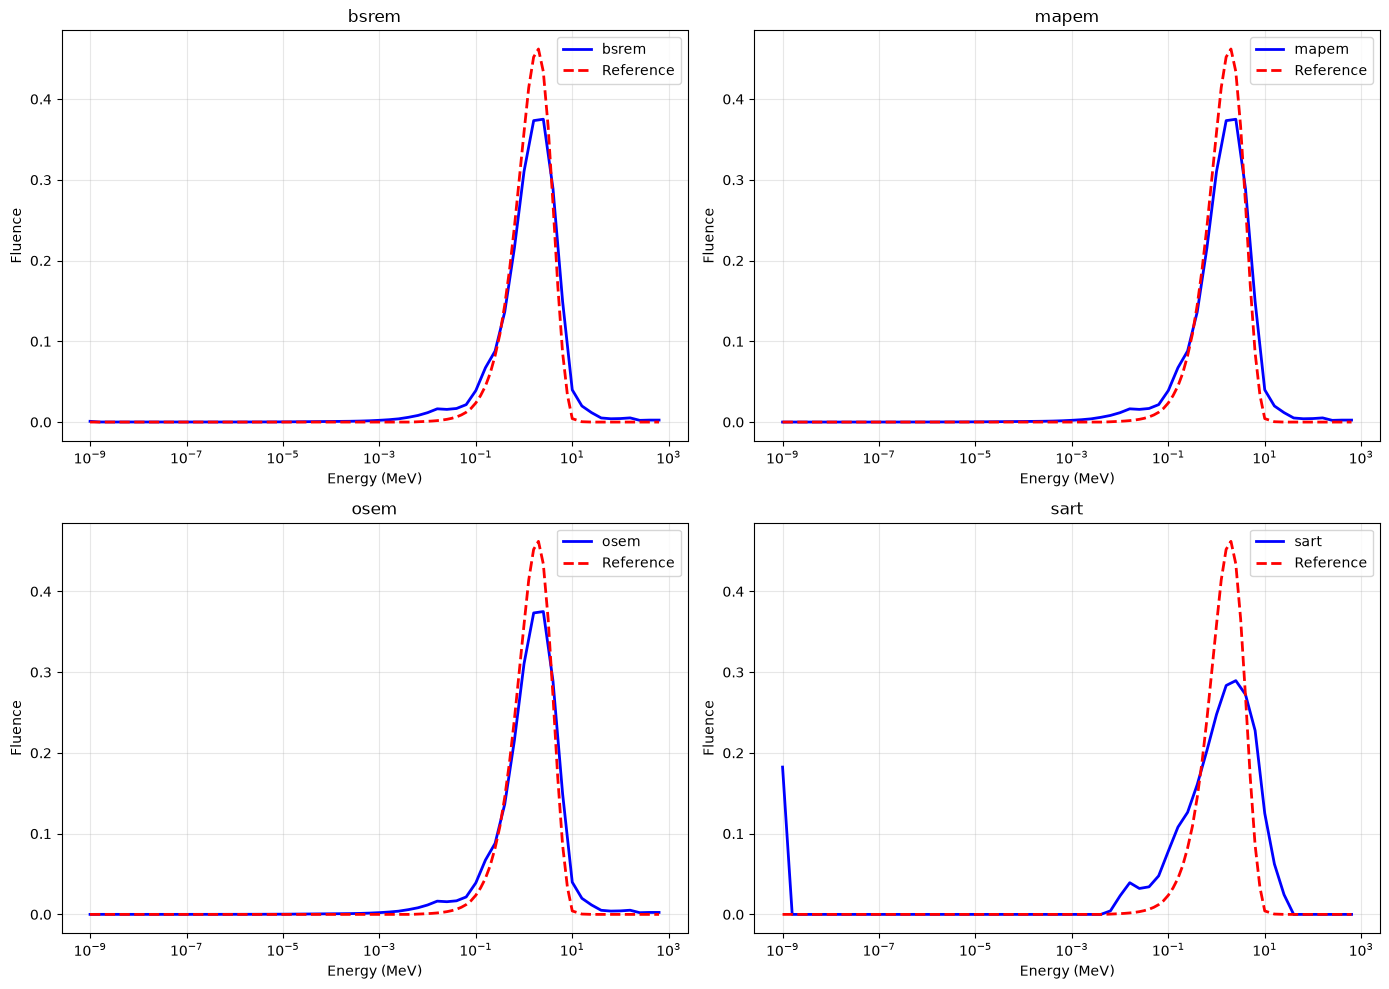

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    ax.plot(det.E_MeV, result['spectrum'], 'b-', label=f'{name}', linewidth=2)
    ax.plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'], 'r--', label='Reference', linewidth=2)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Fluence')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('linear')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated four tomography-based reconstruction methods adapted for neutron spectrum unfolding:

1. **BSREM**: Block-Sequential Regularized EM - provides regularization during iterative updates
2. **MAP-EM**: Maximum A Posteriori EM - incorporates prior information into the reconstruction
3. **OSEM**: Ordered Subsets EM - accelerates convergence by processing subsets of data
4. **SART**: Simultaneous Algebraic Reconstruction Technique - algebraic approach from CT imaging

These methods originate from medical imaging and tomography, adapted here for the neutron spectrum unfolding problem. They offer different trade-offs between convergence speed, noise handling, and computational requirements.